In [2]:
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

In [3]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "2"

In [4]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch

sys.path.append("src")
from entropy_pruning import (
    AttentionForecaster,
    MLPForecaster,
    ConvForecaster,
    UNILoRAClassifier,
    build_attention_cache,
    build_loaders,
    set_seed,
    train_forecaster,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

/home/vcivale/miniconda3/envs/entropy_pruning/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


In [5]:
import numpy as np
import h5py
from torch.utils.data import DataLoader, TensorDataset

CFG = dict(
    data_dir="/raid/DATASETS/NCT-CRC-HE",
    img_size=224,
    batch_size=512,       # aumentato: modello piccolo, VRAM lo regge
    num_workers=4,        # FIX #1: data loading parallelo
    seed=42,
    layer_source=2,
    layer_target=23,
    epochs=30,
    lr=1e-4,
    weight_decay=0.05,
)

# --- Architecture configurations ---
ARCH_CONFIGS = [
    # (name, model_class, kwargs)
    ("Attention h=128 L=1", AttentionForecaster, dict(hidden=128, n_heads=4, n_layers=1, dropout=0.1)),
    ("Attention h=256 L=1", AttentionForecaster, dict(hidden=256, n_heads=4, n_layers=1, dropout=0.1)),
    ("Attention h=128 L=2", AttentionForecaster, dict(hidden=128, n_heads=4, n_layers=2, dropout=0.1)),
    ("Attention h=256 L=2", AttentionForecaster, dict(hidden=256, n_heads=4, n_layers=2, dropout=0.1)),
    ("Attention h=256 L=3", AttentionForecaster, dict(hidden=256, n_heads=4, n_layers=3, dropout=0.1)),
    ("MLP h=256 L=2",       MLPForecaster,       dict(hidden=256, n_layers=2, dropout=0.1)),
    ("MLP h=256 L=3",       MLPForecaster,       dict(hidden=256, n_layers=3, dropout=0.1)),
    ("MLP h=512 L=3",       MLPForecaster,       dict(hidden=512, n_layers=3, dropout=0.1)),
    ("Conv h=256 L=2 k=5",  ConvForecaster,      dict(hidden=256, n_layers=2, dropout=0.1, kernel_size=5)),
    ("Conv h=256 L=3 k=5",  ConvForecaster,      dict(hidden=256, n_layers=3, dropout=0.1, kernel_size=5)),
    ("Conv h=256 L=2 k=9",  ConvForecaster,      dict(hidden=256, n_layers=2, dropout=0.1, kernel_size=9)),
]

set_seed(CFG["seed"])
dataset_name = Path(CFG["data_dir"]).name
classifier_ckpt = Path(f"/raid/DATASETS/checkpoints-Attention-Pruning/{dataset_name}/uni_finetuned/best_model.pt")
cache_path = Path(f"/raid/DATASETS/NCT-CRC-HE/data_cache/{dataset_name}_forecaster_dataset.h5")
forecaster_dir = Path(f"/raid/DATASETS/checkpoints-Attention-Pruning//{dataset_name}/arch_ablation")
forecaster_dir.mkdir(parents=True, exist_ok=True)

print(f"Architectures: {len(ARCH_CONFIGS)}")
for name, cls, kw in ARCH_CONFIGS:
    print(f"  {name} ({cls.__name__})")

Architectures: 11
  Attention h=128 L=1 (AttentionForecaster)
  Attention h=256 L=1 (AttentionForecaster)
  Attention h=128 L=2 (AttentionForecaster)
  Attention h=256 L=2 (AttentionForecaster)
  Attention h=256 L=3 (AttentionForecaster)
  MLP h=256 L=2 (MLPForecaster)
  MLP h=256 L=3 (MLPForecaster)
  MLP h=512 L=3 (MLPForecaster)
  Conv h=256 L=2 k=5 (ConvForecaster)
  Conv h=256 L=3 k=5 (ConvForecaster)
  Conv h=256 L=2 k=9 (ConvForecaster)


In [15]:
loaders = build_loaders(
    data_dir=CFG["data_dir"],
    img_size=CFG["img_size"],
    batch_size=CFG["batch_size"],
    num_workers=CFG["num_workers"],
    drop_last_train=False,
)

model = UNILoRAClassifier(loaders.n_classes).to(device)
model.load_state_dict(torch.load(classifier_ckpt, map_location=device), strict=False)
model.eval()
for p in model.parameters():
    p.requires_grad_(False)

if not cache_path.exists():
    build_attention_cache(
        model=model,
        loaders={"train": loaders.train_loader, "val": loaders.val_loader, "test": loaders.test_loader},
        device=device,
        source_layers=[CFG["layer_source"]],
        target_layers=[CFG["layer_target"]],
        save_path=cache_path,
    )
print("Cache:", cache_path)

del model
torch.cuda.empty_cache()

Cache: /raid/DATASETS/NCT-CRC-HE/data_cache/NCT-CRC-HE_forecaster_dataset.h5


In [16]:
# FIX #2: carica tutto il dataset in RAM → elimina HDF5 I/O durante il training
def load_split_to_tensors(h5_path, split, layer_source, layer_target):
    with h5py.File(h5_path, "r") as f:
        if split not in f:
            split = "validation" if split == "val" else "val"
        grp = f[split]
        emb    = torch.from_numpy(grp[f"emb_layer{layer_source}"][:]).float()
        target = torch.from_numpy(grp[f"attn_layer{layer_target}"][:]).float()
        labels = torch.from_numpy(grp["labels"][:]).long()
    return TensorDataset(emb, target, labels)

print("Caricamento dataset in RAM...")
train_ds_mem = load_split_to_tensors(cache_path, "train", CFG["layer_source"], CFG["layer_target"])
val_ds_mem   = load_split_to_tensors(cache_path, "val",   CFG["layer_source"], CFG["layer_target"])
test_ds_mem  = load_split_to_tensors(cache_path, "test",  CFG["layer_source"], CFG["layer_target"])
print(f"  train: {len(train_ds_mem):,}  val: {len(val_ds_mem):,}  test: {len(test_ds_mem):,}")

loader_kw = dict(batch_size=CFG["batch_size"], num_workers=CFG["num_workers"],
                 pin_memory=True, persistent_workers=True)
train_loader_mem = DataLoader(train_ds_mem, shuffle=True,  **loader_kw)
val_loader_mem   = DataLoader(val_ds_mem,   shuffle=False, **loader_kw)
test_loader_mem  = DataLoader(test_ds_mem,  shuffle=False, **loader_kw)

Caricamento dataset in RAM...
  train: 90,000  val: 10,000  test: 7,180


In [17]:
import torch.nn.functional as F
from scipy.stats import spearmanr
from tqdm.auto import tqdm

def spearman_matrix(pred_np, tgt_np):
    """Calcola Spearman rho per ogni sample in modo vettorizzato (evita loop Python)."""
    def rankdata_2d(x):
        idx = np.argsort(x, axis=1)
        ranks = np.empty_like(idx, dtype=float)
        np.put_along_axis(ranks, idx, np.arange(1, x.shape[1]+1, dtype=float)[None], axis=1)
        return ranks
    rp = rankdata_2d(pred_np)
    rt = rankdata_2d(tgt_np)
    diff = rp - rt
    n = pred_np.shape[1]
    return 1 - 6 * (diff**2).sum(axis=1) / (n * (n**2 - 1))


def train_forecaster_fast(forecaster_model, save_path, device, cfg,
                          train_loader, val_loader, test_loader):
    forecaster = forecaster_model.to(device)
    opt = torch.optim.AdamW(forecaster.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg["epochs"])

    best_val_kl = float("inf")
    best_val_rho = -1.0

    for epoch in tqdm(range(cfg["epochs"]), desc="epochs", leave=False):
        # --- train ---
        forecaster.train()
        for emb, target, _ in tqdm(train_loader, leave=False):
            emb, target = emb.to(device, non_blocking=True), target.to(device, non_blocking=True)
            pred = forecaster(emb)
            kl  = F.kl_div((pred + 1e-8).log(), target + 1e-8, reduction="batchmean")
            mse = F.mse_loss(pred, target)
            loss = kl + 0.1 * mse
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(forecaster.parameters(), 1.0)
            opt.step()

        # --- val: accumula tutto, sync unico alla fine ---
        forecaster.eval()
        val_kl_acc = torch.zeros(1, device=device)
        all_pred, all_tgt = [], []
        with torch.no_grad():
            for emb, target, _ in val_loader:
                emb, target = emb.to(device, non_blocking=True), target.to(device, non_blocking=True)
                pred = forecaster(emb)
                val_kl_acc += F.kl_div((pred + 1e-8).log(), target + 1e-8, reduction="batchmean")
                all_pred.append(pred)
                all_tgt.append(target)

        pred_np = torch.cat(all_pred).cpu().numpy()
        tgt_np  = torch.cat(all_tgt).cpu().numpy()
        val_kl  = (val_kl_acc / len(val_loader)).item()
        val_rho = float(np.nanmean(spearman_matrix(pred_np, tgt_np)))

        if val_kl < best_val_kl:
            best_val_kl  = val_kl
            best_val_rho = val_rho
            torch.save(forecaster.state_dict(), save_path)

        sched.step()

    forecaster.load_state_dict(torch.load(save_path, map_location=device))
    forecaster.eval()

    test_rhos_f, test_rhos_n = [], []
    with torch.no_grad():
        for emb, target, _ in test_loader:
            pred   = forecaster(emb.to(device, non_blocking=True)).cpu().numpy()
            tgt    = target.numpy()
            norms  = emb.norm(dim=-1).numpy()
            test_rhos_f.extend(spearman_matrix(pred, tgt).tolist())
            test_rhos_n.extend(spearman_matrix(norms, tgt).tolist())

    return {
        "best_val_kl": best_val_kl,
        "best_val_rho": best_val_rho,
        "test_rho_forecaster": float(np.nanmean(test_rhos_f)),
        "test_rho_token_norm": float(np.nanmean(test_rhos_n)),
        "model": forecaster,
    }


all_results = []
for i, (arch_name, model_cls, model_kwargs) in enumerate(ARCH_CONFIGS):
    tag = arch_name.replace(" ", "_").replace("=", "")
    print(f"\n[{i+1}/{len(ARCH_CONFIGS)}] {arch_name}")

    save_path = forecaster_dir / f"forecaster_{tag}.pt"

    forecaster_model = model_cls(embed_dim=1024, **model_kwargs)
    n_params = sum(p.numel() for p in forecaster_model.parameters())
    print(f"  params: {n_params:,}")

    result = train_forecaster_fast(
        forecaster_model=forecaster_model,
        save_path=save_path,
        device=device,
        cfg=CFG,
        train_loader=train_loader_mem,
        val_loader=val_loader_mem,
        test_loader=test_loader_mem,
    )

    result["arch_name"] = arch_name
    result["arch_class"] = model_cls.__name__
    result["n_params"] = n_params
    all_results.append(result)

    print(f"  rho={result['test_rho_forecaster']:.4f}  val_kl={result['best_val_kl']:.4f}")
    del result["model"]
    torch.cuda.empty_cache()


[1/11] Attention h=128 L=1
  params: 363,393


  rho=0.6803  val_kl=-0.3397

[2/11] Attention h=256 L=1
  params: 1,119,745


  rho=0.6996  val_kl=-0.3410

[3/11] Attention h=128 L=2
  params: 562,177


  rho=0.6905  val_kl=-0.3402

[4/11] Attention h=256 L=2
  params: 1,910,529


  rho=0.7249  val_kl=-0.3419

[5/11] Attention h=256 L=3
  params: 2,701,313


...

  rho=0.6236  val_kl=-0.3367

[8/11] MLP h=512 L=3
  params: 1,050,625


  rho=0.6270  val_kl=-0.3369

[9/11] Conv h=256 L=2 k=5
  params: 1,639,169


  rho=0.6686  val_kl=-0.3389

[10/11] Conv h=256 L=3 k=5
  params: 1,967,105


  rho=0.6698  val_kl=-0.3390

[11/11] Conv h=256 L=2 k=9
  params: 2,949,889


  rho=0.6684  val_kl=-0.3391


In [18]:
df = pd.DataFrame([
    {
        "architecture": r["arch_name"],
        "class": r["arch_class"],
        "n_params": r["n_params"],
        "best_val_kl": r["best_val_kl"],
        "best_val_rho": r["best_val_rho"],
        "test_rho_forecaster": r["test_rho_forecaster"],
        "test_rho_token_norm": r["test_rho_token_norm"],
        "delta_rho": r["test_rho_forecaster"] - r["test_rho_token_norm"],
    }
    for r in all_results
])
df = df.sort_values("test_rho_forecaster", ascending=False).reset_index(drop=True)
Path("results").mkdir(exist_ok=True)
df.to_csv(f"results/arch_ablation_{dataset_name}.csv", index=False)
df

,architecture,class,n_params,best_val_kl,best_val_rho,test_rho_forecaster,test_rho_token_norm,delta_rho
0,Attention h=256 L=2,AttentionForecaster,1910529,-0.341911,0.785016,0.724901,0.11809,0.606811
1,Attention h=256 L=3,AttentionForecaster,2701313,-0.341856,0.783710,0.724241,0.11809,0.606151
2,Attention h=256 L=1,AttentionForecaster,1119745,-0.340994,0.768400,0.699564,0.11809,0.581474
3,Attention h=128 L=2,AttentionForecaster,562177,-0.340212,0.753575,0.690533,0.11809,0.572443
4,Attention h=128 L=1,AttentionForecaster,363393,-0.339705,0.745295,0.680332,0.11809,0.562242
5,Conv h=256 L=3 k=5,ConvForecaster,1967105,-0.339024,0.733016,0.669768,0.11809,0.551678
6,Conv h=256 L=2 k=5,ConvForecaster,1639169,-0.338921,0.731601,0.668607,0.11809,0.550517
7,Conv h=256 L=2 k=9,ConvForecaster,2949889,-0.339108,0.733515,0.668426,0.11809,0.550336
8,MLP h=512 L=3,MLPForecaster,1050625,-0.336913,0.693142,0.627045,0.11809,0.508955
9,MLP h=256 L=3,MLPForecaster,394241,-0.336731,0.689180,0.623607,0.11809,0.505517


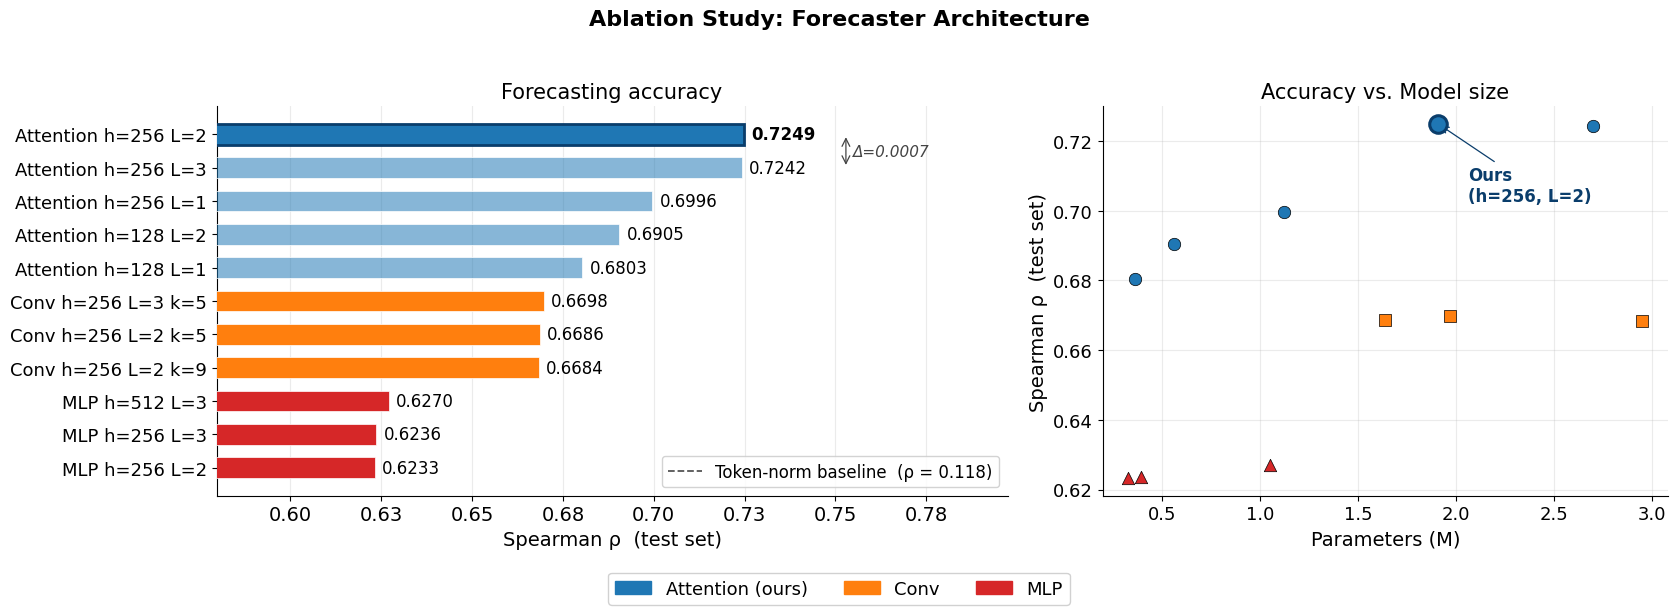

Saved → results/arch_ablation_NCT-CRC-HE_final.png


In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

# ── load results ──────────────────────────────────────────────────────────────
df_plot = pd.read_csv(f"results/arch_ablation_{dataset_name}.csv")
df_plot = df_plot.sort_values("test_rho_forecaster", ascending=False).reset_index(drop=True)

OURS = "Attention h=256 L=2"

# ── palette by family ─────────────────────────────────────────────────────────
FAMILY_COLOR = {
    "AttentionForecaster": "#1f77b4",
    "MLPForecaster":       "#d62728",
    "ConvForecaster":      "#ff7f0e",
}
OURS_EDGE = "#0a3d6b"

def bar_color(row):
    c = FAMILY_COLOR[row["class"]]
    if row["class"] == "AttentionForecaster" and row["architecture"] != OURS:
        return c + "88"
    return c

palette = [bar_color(row) for _, row in df_plot.iterrows()]

# ── style ─────────────────────────────────────────────────────────────────────
FONT = 14
plt.rcParams.update({
    "font.family":       "sans-serif",
    "font.size":         FONT,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.linewidth":    0.8,
})

baseline_rho = df_plot["test_rho_token_norm"].iloc[0]
labels       = df_plot["architecture"].tolist()
x            = np.arange(len(labels))
bar_w        = 0.62

fig, axes = plt.subplots(1, 2, figsize=(17, 5.5),
                         gridspec_kw={"width_ratios": [1.4, 1]})
fig.suptitle("Ablation Study: Forecaster Architecture", fontsize=FONT + 2,
             fontweight="bold", y=1.02)

# ── LEFT: horizontal bar — test Spearman ρ ───────────────────────────────────
ax = axes[0]
bars = ax.barh(x, df_plot["test_rho_forecaster"], height=bar_w,
               color=palette, edgecolor="white", linewidth=0.5, zorder=3)

ours_idx = df_plot[df_plot["architecture"] == OURS].index[0]
bars[ours_idx].set_edgecolor(OURS_EDGE)
bars[ours_idx].set_linewidth(2.0)

ax.axvline(baseline_rho, color="#555", ls="--", lw=1.3, zorder=2,
           label=f"Token-norm baseline  (ρ = {baseline_rho:.3f})")

for i, (bar, val) in enumerate(zip(bars, df_plot["test_rho_forecaster"])):
    fw = "bold" if i == ours_idx else "normal"
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=FONT - 2, fontweight=fw)

# Δ bracket between rank-1 and rank-2
y0 = bars[0].get_y() + bar_w / 2
y1 = bars[1].get_y() + bar_w / 2
xr = df_plot["test_rho_forecaster"].max() + 0.028
ax.annotate("", xy=(xr, y1), xytext=(xr, y0),
            arrowprops=dict(arrowstyle="<->", color="#444", lw=0.9))
d = df_plot["test_rho_forecaster"].iloc[0] - df_plot["test_rho_forecaster"].iloc[1]
ax.text(xr + 0.002, (y0 + y1) / 2, f"Δ={d:.4f}", va="center",
        fontsize=FONT - 3, color="#444", style="italic")

ax.set_yticks(x)
ax.set_yticklabels(labels, fontsize=FONT - 1)
ax.invert_yaxis()
ax.set_xlabel("Spearman ρ  (test set)", fontsize=FONT)
ax.set_title("Forecasting accuracy", fontsize=FONT + 1)
ax.set_xlim(df_plot["test_rho_forecaster"].min() * 0.93,
            df_plot["test_rho_forecaster"].max() * 1.1)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.legend(fontsize=FONT - 2, framealpha=0.85, loc="lower right")
ax.grid(axis="x", alpha=0.25, zorder=0)

# ── RIGHT: scatter — params vs ρ ─────────────────────────────────────────────
ax3 = axes[1]
for cls_name, color, marker, label in [
    ("AttentionForecaster", "#1f77b4", "o", "Attention"),
    ("ConvForecaster",      "#ff7f0e", "s", "Conv"),
    ("MLPForecaster",       "#d62728", "^", "MLP"),
]:
    mask = df_plot["class"] == cls_name
    ax3.scatter(df_plot.loc[mask, "n_params"] / 1e6,
                df_plot.loc[mask, "test_rho_forecaster"],
                color=color, marker=marker, s=80,
                edgecolors="k", linewidths=0.5, zorder=4)

# highlight ours
row = df_plot[df_plot["architecture"] == OURS].iloc[0]
ax3.scatter(row["n_params"] / 1e6, row["test_rho_forecaster"],
            color="#1f77b4", marker="o", s=160,
            edgecolors=OURS_EDGE, linewidths=2.2, zorder=5)
ax3.annotate("Ours\n(h=256, L=2)",
             xy=(row["n_params"] / 1e6, row["test_rho_forecaster"]),
             xytext=(row["n_params"] / 1e6 + 0.15, row["test_rho_forecaster"] - 0.022),
             fontsize=FONT - 2, color=OURS_EDGE, fontweight="bold",
             arrowprops=dict(arrowstyle="->", color=OURS_EDGE, lw=0.9))

ax3.set_xlabel("Parameters (M)", fontsize=FONT)
ax3.set_ylabel("Spearman ρ  (test set)", fontsize=FONT)
ax3.set_title("Accuracy vs. Model size", fontsize=FONT + 1)
ax3.tick_params(labelsize=FONT - 1)
ax3.grid(alpha=0.25, zorder=0)
ax3.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

# ── family legend (bottom, shared) ───────────────────────────────────────────
family_patches = [
    mpatches.Patch(color="#1f77b4", label="Attention (ours)"),
    mpatches.Patch(color="#ff7f0e", label="Conv"),
    mpatches.Patch(color="#d62728", label="MLP"),
]
fig.legend(handles=family_patches, loc="lower center", ncol=3,
           bbox_to_anchor=(0.5, -0.08), fontsize=FONT - 1, framealpha=0.9)

plt.tight_layout()
out_path = f"results/arch_ablation_{dataset_name}_final.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved → {out_path}")


In [20]:
print("Risultati ablation architettura:\n")
print(df[["architecture", "class", "n_params", "test_rho_forecaster",
          "test_rho_token_norm", "delta_rho", "best_val_kl"]].to_string(index=False))

Risultati ablation architettura:

       architecture               class  n_params  test_rho_forecaster  test_rho_token_norm  delta_rho  best_val_kl
Attention h=256 L=2 AttentionForecaster   1910529             0.724901              0.11809   0.606811    -0.341911
Attention h=256 L=3 AttentionForecaster   2701313             0.724241              0.11809   0.606151    -0.341856
Attention h=256 L=1 AttentionForecaster   1119745             0.699564              0.11809   0.581474    -0.340994
Attention h=128 L=2 AttentionForecaster    562177             0.690533              0.11809   0.572443    -0.340212
Attention h=128 L=1 AttentionForecaster    363393             0.680332              0.11809   0.562242    -0.339705
 Conv h=256 L=3 k=5      ConvForecaster   1967105             0.669768              0.11809   0.551678    -0.339024
 Conv h=256 L=2 k=5      ConvForecaster   1639169             0.668607              0.11809   0.550517    -0.338921
 Conv h=256 L=2 k=9      ConvForecaste